In [2]:
import jax.numpy as jnp

In [156]:
import ase
import ase.io as ase_io
import ase.visualize.plot
traj_x = ase_io.read("ell4_100x.traj", index=":")
traj_xn = ase_io.read("ell4_100xn.traj", index=":")

In [157]:
len(traj_x)

10002

<Axes: >

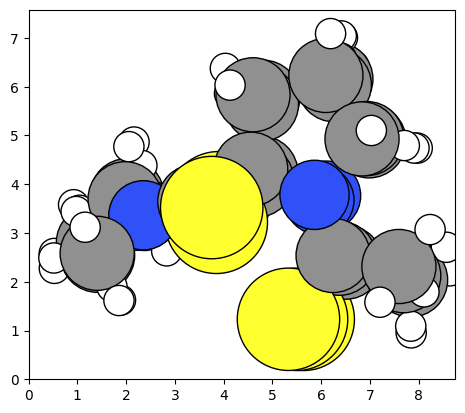

In [158]:
from ase.visualize.plot import plot_atoms as plot_atoms

plot_atoms(traj_x[0])
plot_atoms(traj_x[3000])
plot_atoms(traj_x[4000])

<Axes: >

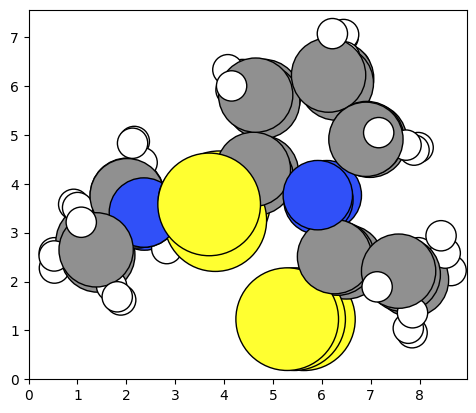

In [166]:
plot_atoms(traj_xn[0])
plot_atoms(traj_xn[3000])
plot_atoms(traj_xn[4000])

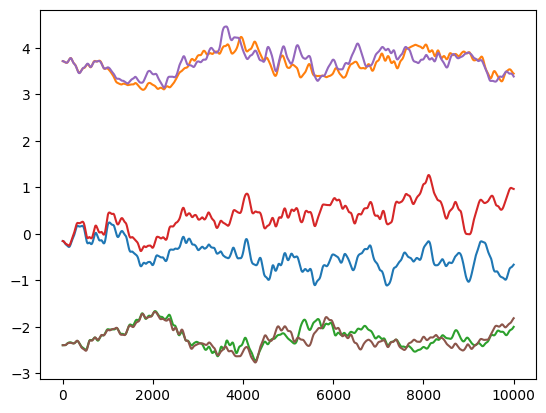

In [165]:
dipm = [_.get_dipole_moment() for _ in traj_x]
xdipm = [_.get_dipole_moment() for _ in traj_xn]
dipm
plt.plot(dipm)
plt.plot(xdipm)

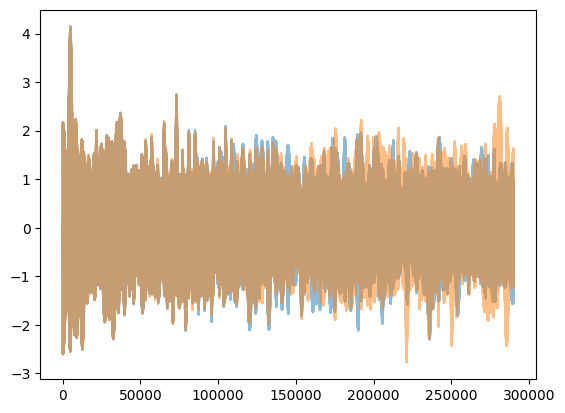

In [174]:
forces = np.array([_.get_forces() for _ in traj_x])
xforces = np.array([_.get_forces() for _ in traj_xn])#, alpha=0.5)
plt.plot(forces.reshape(-1,3)[:,0], alpha=0.5)
plt.plot(xforces.reshape(-1,3)[:,0], alpha=0.5)

(array([3.20000e+02, 3.15000e+03, 2.10070e+04, 1.13377e+05, 1.20643e+05,
        2.27730e+04, 3.45100e+03, 3.05000e+02, 1.10000e+01, 2.10000e+01]),
 array([-2.77398086, -2.08390737, -1.39383388, -0.70376039, -0.0136869 ,
         0.67638659,  1.36646008,  2.05653358,  2.74660707,  3.43668056,
         4.12675381]),
 <BarContainer object of 10 artists>)

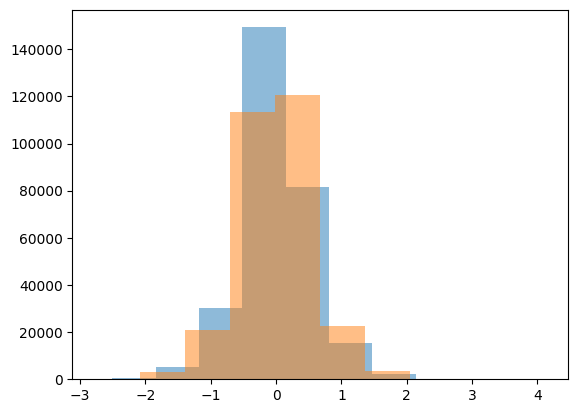

In [178]:
plt.hist(forces.reshape(-1,3)[5000:,0], alpha=0.5)
plt.hist(xforces.reshape(-1,3)[5000:,0], alpha=0.5)

In [179]:
import numpy as np
from ase.io import read, write

def kabsch_align(mobile_xyz, ref_xyz):
    """Return mobile_xyz rigidly aligned to ref_xyz (same atom order)."""
    # Remove COM
    mob_com = mobile_xyz.mean(axis=0)
    ref_com = ref_xyz.mean(axis=0)
    X = mobile_xyz - mob_com
    Y = ref_xyz - ref_com

    # Kabsch rotation
    C = X.T @ Y
    V, S, Wt = np.linalg.svd(C)
    d = np.sign(np.linalg.det(V @ Wt))
    D = np.diag([1.0, 1.0, d])
    R = V @ D @ Wt

    # Rotate + translate onto reference COM
    X_aligned = X @ R
    return X_aligned + ref_com

def rmsd(a, b):
    return np.sqrt(np.mean(np.sum((a - b) ** 2, axis=1)))

traj_x = ase_io.read("ell4_100x.traj", index=":")
traj_xn = ase_io.read("ell4_100xn.traj", index=":")
# Read all frames from an ASE trajectory-like file (.traj, .xyz, etc.)
frames = traj_x #read("traj.traj", index=":")
frames2 = traj_xn
ref = frames[0].copy()

# Optional: align only a subset (e.g. heavy atoms)
# sel = [i for i, Z in enumerate(ref.get_atomic_numbers()) if Z > 1]
sel = np.arange(len(ref))

aligned_frames = []
aligned_frames2 = []
rmsd_values = []
rmsd_values2 = []

ref_sel = ref.positions[sel]
for at in frames:
    at2 = at.copy()
    pos = at2.positions.copy()
    pos_sel_aligned = kabsch_align(pos[sel], ref_sel)

    # Apply same rigid transform to ALL atoms:
    # recover transform from selected atoms
    mob_com = pos[sel].mean(axis=0)
    ref_com = ref_sel.mean(axis=0)
    X = pos[sel] - mob_com
    Y = ref_sel - ref_com
    V, S, Wt = np.linalg.svd(X.T @ Y)
    d = np.sign(np.linalg.det(V @ Wt))
    R = V @ np.diag([1.0, 1.0, d]) @ Wt
    pos_aligned = (pos - mob_com) @ R + ref_com

    at2.positions = pos_aligned
    aligned_frames.append(at2)
    rmsd_values.append(rmsd(pos_aligned[sel], ref_sel))

for at in frames2:
    at2 = at.copy()
    pos = at2.positions.copy()
    pos_sel_aligned = kabsch_align(pos[sel], ref_sel)

    # Apply same rigid transform to ALL atoms:
    # recover transform from selected atoms
    mob_com = pos[sel].mean(axis=0)
    ref_com = ref_sel.mean(axis=0)
    X = pos[sel] - mob_com
    Y = ref_sel - ref_com
    V, S, Wt = np.linalg.svd(X.T @ Y)
    d = np.sign(np.linalg.det(V @ Wt))
    R = V @ np.diag([1.0, 1.0, d]) @ Wt
    pos_aligned = (pos - mob_com) @ R + ref_com

    at2.positions = pos_aligned
    aligned_frames2.append(at2)
    rmsd_values2.append(rmsd(pos_aligned[sel], ref_sel))

write("traj_aligned.traj", aligned_frames)
print("First 10 RMSDs (A):", np.array(rmsd_values[:10]))

First 10 RMSDs (A): [1.77244295e-15 1.77244295e-15 2.43040387e-05 9.71789372e-05
 2.18513337e-04 3.88121584e-04 6.05743860e-04 8.71046447e-04
 1.18362196e-03 1.54298957e-03]


In [186]:
len(aligned_frames2)

10002

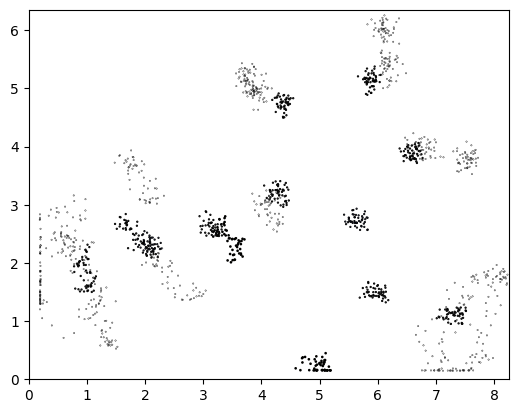

In [195]:
for i in range(50):
    plot_atoms(aligned_frames2[3000+i*100], radii=0.01)
    # plot_atoms(aligned_frames[5000+i*10], radii=0.1)

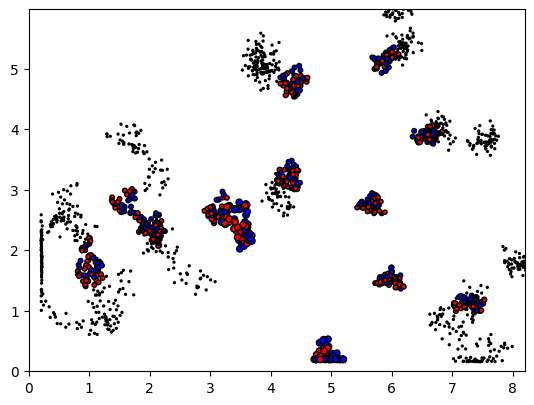

In [207]:
for i in range(30):
    plot_atoms(aligned_frames2[6000+i*100], radii=0.05, colors=["b"]*len(aligned_frames[3000+i*100]))
    plot_atoms(aligned_frames[6000+i*100], radii=0.05, colors=["r"]*len(aligned_frames[3000+i*100]))

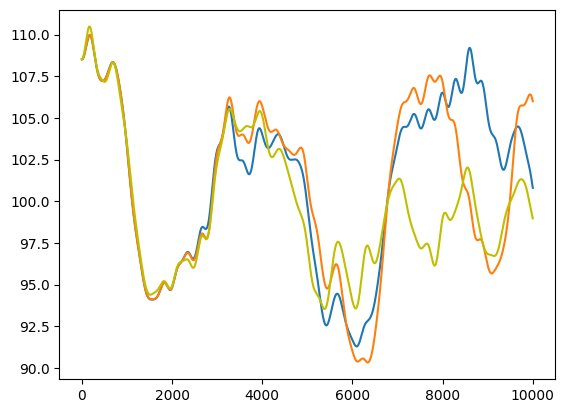

In [218]:
traj_x = ase_io.read("ell4_100x.traj", index=":")
traj_xn = ase_io.read("ell4_100xn.traj", index=":")
R = np.array([_.get_positions() for _ in traj_x])
dihs_ = R[:,[0, 2, 9, 11],:]
out_dihs_trajx = batched_dih(dihs_.reshape((-1, 4, 3))).reshape(-1)

R = np.array([_.get_positions() for _ in traj_xn])
dihs_ = R[:,[0, 2, 9, 11],:]
out_dihs_trajxn = batched_dih(dihs_.reshape((-1, 4, 3))).reshape(-1)
plt.plot(out_dihs_trajx)
plt.plot(out_dihs_trajxn)
plt.plot(out_dihs[:,0], color="y")


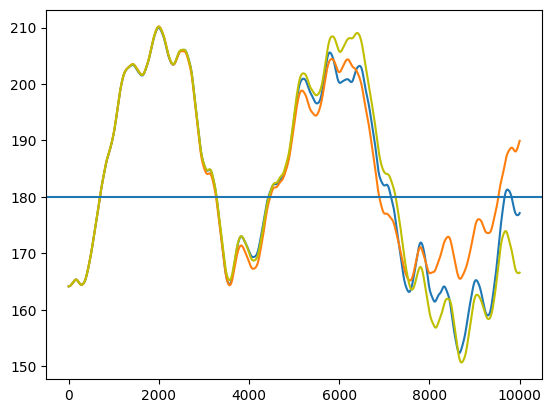

In [233]:
traj_x = ase_io.read("ell4_100x.traj", index=":")
traj_xn = ase_io.read("ell4_100xn.traj", index=":")
R = np.array([_.get_positions() for _ in traj_x])
dihs_ = R[:,[3, 4, 1, 0],:]
out_dihs_trajx = batched_dih(dihs_.reshape((-1, 4, 3))).reshape(-1)

R = np.array([_.get_positions() for _ in traj_xn])
dihs_ = R[:,[3, 4, 1, 0],:]
out_dihs_trajxn = batched_dih(dihs_.reshape((-1, 4, 3))).reshape(-1)

_ = jnp.load("ell4_100.npz")
R = _["R"]
dihs_ = R[:,:,[3, 4, 1, 0],:]
out_dihs2ell4_100 = batched_dih(dihs_.reshape((-1, 4, 3))).reshape(-1, 10,)



plt.plot(((out_dihs_trajx)) % 360)
plt.plot( (out_dihs_trajxn) % 360)
plt.plot((out_dihs2ell4_100[:,0]) % 360, color="y" )
plt.axhline(180)

In [161]:
energies = [_.get_potential_energy() for _ in traj_x]
total_energies = [_.get_total_energy() for _ in traj_x]
kin_energies = [_.get_kinetic_energy() for _ in traj_x]
nenergies = [_.get_potential_energy() for _ in traj_xn]
ntotal_energies = [_.get_total_energy() for _ in traj_xn]
nkin_energies = [_.get_kinetic_energy() for _ in traj_xn]

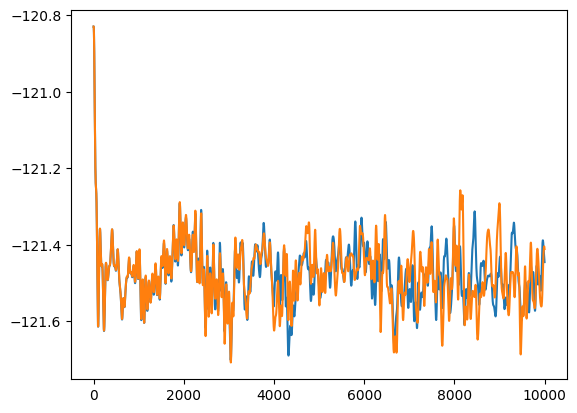

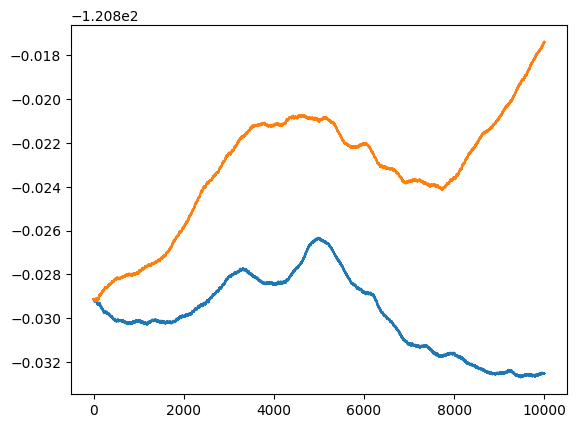

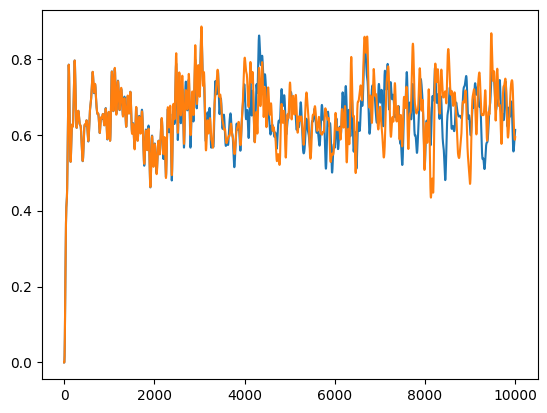

In [162]:
plt.plot(energies)
plt.plot(nenergies)
plt.show()
plt.plot(total_energies)
plt.plot(ntotal_energies)
plt.show()
plt.plot(kin_energies)
plt.plot(nkin_energies)
plt.show()

In [5]:
ell4 = jnp.load("ell4.npz")

In [30]:
ell4["R"].shape

(10001, 10, 29, 3)

In [14]:
R = ell4["R"]
Z = ell4["Z"]
for i in range(len(Z)):
    print(i, Z[i])

0 16
1 6
2 7
3 6
4 6
5 6
6 6
7 6
8 6
9 7
10 6
11 16
12 6
13 1
14 1
15 1
16 1
17 1
18 1
19 1
20 1
21 1
22 1
23 1
24 1
25 1
26 1
27 1
28 1


In [45]:
import jax

def _norm(x: np.ndarray) -> float:
    return float(np.linalg.norm(x))

def dih(p,  eps=1e-12):
    # p: (4, 3)
    b0 = p[0] - p[1]
    b1 = p[2] - p[1]
    b2 = p[3] - p[2]

    b1n = b1 / jnp.maximum(jnp.linalg.norm(b1), eps)
    v = b0 - jnp.dot(b0, b1n) * b1n
    w = b2 - jnp.dot(b2, b1n) * b1n

    x = jnp.dot(v, w)
    y = jnp.dot(jnp.cross(b1n, v), w)
    angle = jnp.degrees(jnp.arctan2(y, x))  # already in [-180, 180]

    # Optional clamp logic kept to mirror your original function:
    angle = jnp.where(angle > 180.0, angle - 360.0, angle)
    angle = jnp.where(angle < -180.0, angle + 360.0, angle)
    return angle



# P: (N, 4, 3) -> angles: (N,)
batched_dih = jax.vmap(dih, in_axes=(0), out_axes=0)
# Optional JIT:batched_dih = jax.jit(batched_dih)


In [129]:
_ = jnp.load("ell0.npz")
R = _["R"]
dihs_ = R[:,:,[0, 2, 9, 11],:]
out_dihs0 = batched_dih(dihs_.reshape((-1, 4, 3))).reshape(-1, 30,)
_ = jnp.load("ell2.npz")
R = _["R"]
dihs_ = R[:,:,[0, 2, 9, 11],:]
out_dihs2 = batched_dih(dihs_.reshape((-1, 4, 3))).reshape(-1, 10,)

_ = jnp.load("ell4_100.npz")
R = _["R"]
dihs_ = R[:,:,[0, 2, 9, 11],:]
out_dihs2ell4_100 = batched_dih(dihs_.reshape((-1, 4, 3))).reshape(-1, 10,)

(-180.0, 180.0)

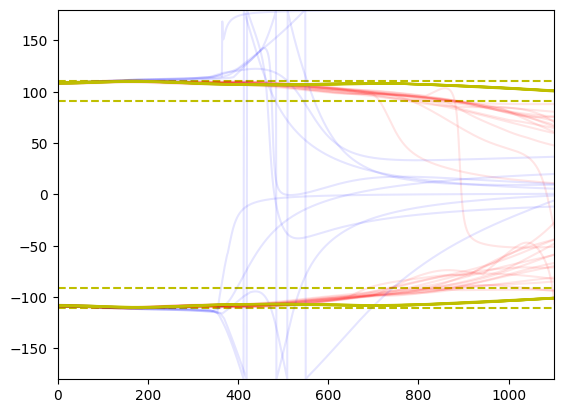

In [134]:
import matplotlib.pyplot as plt
plt.plot(out_dihs, color="y")
plt.axhline(out_dihs[:,0::2].min(), color="y", linestyle="--")
plt.axhline(out_dihs[:,0::2].max(), color="y", linestyle="--")
plt.axhline(out_dihs[:,1::2].min(), color="y", linestyle="--")
plt.axhline(out_dihs[:,1::2].max(), color="y", linestyle="--")
plt.plot(out_dihs0, alpha=0.1, color="r")
plt.plot(out_dihs2, alpha=0.1, color="b")
plt.plot(out_dihs2ell4_100, alpha=0.9, color="y")

plt.xlim(0,1100)
plt.ylim(-180,180)

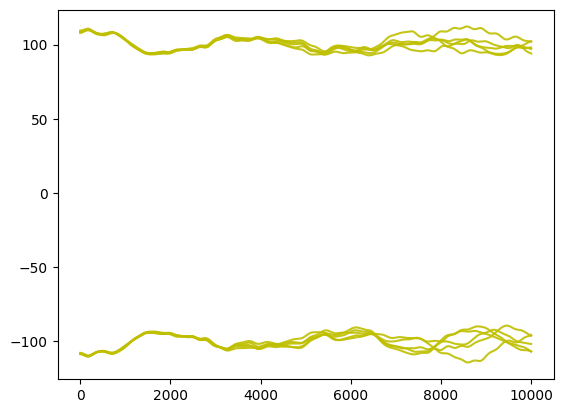

In [132]:
plt.plot(out_dihs2ell4_100, alpha=0.9, color="y")

(array([    0.,   160.,  7667., 16322., 12933.,  8308.,  3744.,   871.,
            0.,     0.]),
 array([ 85. ,  88.5,  92. ,  95.5,  99. , 102.5, 106. , 109.5, 113. ,
        116.5, 120. ]),
 <BarContainer object of 10 artists>)

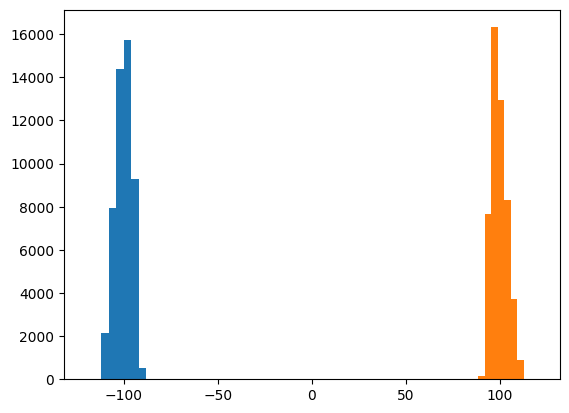

In [95]:
plt.hist(out_dihs.flatten(), range=(-120, -80))
plt.hist(out_dihs.flatten(), range=(85, 120))

In [106]:
out_dihs.min()

Array(-110.707596, dtype=float32)

In [107]:
out_dihs.max()

Array(110.62177, dtype=float32)

In [108]:
data_train = jnp.load("data-full.npz", allow_pickle=True)

In [109]:
data_train

NpzFile 'data-full.npz' with keys: R, Z, D, E, F...

In [136]:
data_train["R"]

array([[[[-0.856624, 0.129623, 1.934218],
         [-1.113226, 0.208861, 0.29253],
         [-2.395473, -0.129327, -0.244816],
         ...,
         [3.221661, -0.929147, 1.445703],
         [3.053021, -2.547992, 0.761525],
         [3.882805, -1.269515, -0.230995]]],


       [[[0.857171, 0.11295, 1.933472],
         [1.094587, 0.199589, 0.312627],
         [2.400773, -0.110526, -0.246986],
         ...,
         [-3.206281, -0.93495, 1.453658],
         [-3.863548, -1.29525, -0.211989],
         [-3.046018, -2.597426, 0.756026]]],


       [[[-0.842514, 0.134943, 1.931842],
         [-1.103519, 0.203674, 0.322082],
         [-2.397987, -0.138973, -0.239201],
         ...,
         [3.224724, -0.928305, 1.451876],
         [3.0758, -2.559792, 0.751777],
         [3.851699, -1.281191, -0.238558]]],


       ...,


       [[[0.872975, 0.118662, 1.943759],
         [1.101215, 0.199464, 0.304584],
         [2.404039, -0.13228, -0.257062],
         ...,
         [-3.2299, -0.927025, 1.452

In [120]:
R = jnp.array(data_train["R"], dtype=jnp.float32)
# R.dtype = 
R.shape, R.dtype

((10000, 1, 29, 3), dtype('float32'))

In [122]:
dihs_ = R[:,:,[0, 2, 9, 11],:]
out_dihs_data_train = batched_dih(dihs_.reshape((-1, 4, 3))).reshape(-1)

In [125]:
out_dihs_data_train

Array([ 108.622314, -107.96623 ,  108.70798 , ..., -108.443985,
        108.519035, -109.068   ], dtype=float32)

(array([   0.,    0.,    0.,    0.,    0.,    0., 4926.,   74.,    0.,
           0.]),
 array([ 85. ,  88.5,  92. ,  95.5,  99. , 102.5, 106. , 109.5, 113. ,
        116.5, 120. ]),
 <BarContainer object of 10 artists>)

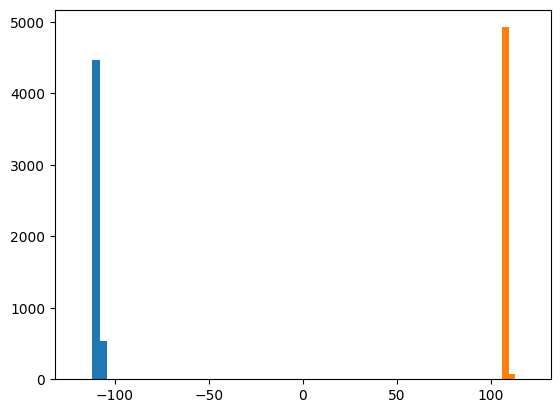

In [126]:
plt.hist(out_dihs_data_train.flatten(), range=(-120, -80))
plt.hist(out_dihs_data_train.flatten(), range=(85, 120))